In [ ]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

In [44]:
import tomllib
import numpy as np
import matplotlib.pyplot as plt

from src.sim_utils import generate_time_index
from src.anl_utils import order_parameter, compute_firing_rate, convert_to_frequency
from src.stimulus_generator import StimulusGenerator
from src.v1_model import V1Model

In [ ]:
sim_results_folder = '../results/simulation'
intrinsic_fr_file = os.path.join(sim_results_folder, 'first_session_intrinsic_firing_rates.npy')
effective_fr_file = os.path.join(sim_results_folder, 'first_session_effective_firing_rates.npy')

While effective firing rate is the actual firing rate exhibited by oscillators towards the end of a smiluation and reflects interactions between oscillators, average effective firing and average intrinsic firing (pure feedforward drive from input) are identical for all conditions in session.

In [8]:
intrinsic_results = np.load(intrinsic_fr_file)
intrinsic_vector = intrinsic_results.mean(axis=0).flatten()

effective_results = np.load(effective_fr_file)
effective_vector = effective_results.mean(axis=0).flatten()

print(f'Are intrinsic and effective firing rates practically equal? {np.allclose(intrinsic_vector, effective_vector)}')
print(f'Total difference: {np.sum(np.abs(intrinsic_vector - effective_vector))}')

Are intrinsic and effective firing rates practically equal? True
Total difference: 2.5934809855243657e-13


This implies that while interactions between oscillators can move firing rates closer to the mean (synchrony), they do not affect the mean. Does this generalize? Is it sensitive to coupling strength?

In [13]:
def load_configurations():
    """
    Load the model, stimulus, simulation, and experiment parameters.

    Returns
    -------
    model_parameters : dict
        The model parameters.
    stimulus_parameters : dict
        The stimulus parameters.
    simulation_parameters : dict
        The simulation parameters.
    """
    parameters = {}
    config_files = ['model', 'stimulus', 'simulation']

    for config_file in config_files:
        with open(f'../config/simulation/{config_file}.toml', 'rb') as f:
            parameters[config_file] = tomllib.load(f)

    return parameters['model'], parameters['stimulus'], parameters[
        'simulation']

In [36]:
model_parameters, stimulus_parameters, simulation_parameters = load_configurations()

stimulus_generator = StimulusGenerator(stimulus_parameters)
stimulus = stimulus_generator.generate(1.5, 0.5, 0.5)

# add num_time_steps
simulation_parameters['num_time_steps'] = int(
        simulation_parameters['simulation_time'] /
        simulation_parameters['time_step'])
sync_index, _ = generate_time_index(simulation_parameters)

Simulation of single stimulus condition but several values of max coupling and coupling decay rate.

In [59]:
effective_firing = np.zeros((10, 10))
intrinsic_firing = np.zeros((10, 10))
synchronization = np.zeros((10, 10))

decay_rate = np.linspace(0.01, 0.25, 10) 
max_coupling = np.linspace(25, 35, 10)


for i, dr in enumerate(decay_rate):
    for j, mc in enumerate(max_coupling):

        model_parameters['decay_rate'] = dr
        model_parameters['max_coupling'] = mc

        model = V1Model(model_parameters, stimulus_parameters)
        model.compute_omega(stimulus.flatten())

        intrinsic_firing[i, j] = convert_to_frequency(model.omega).mean()

        state, _ = model.simulate(simulation_parameters)
        synchronization[i, j] = np.abs(order_parameter(state))[sync_index].mean()

        effective_firing[i, j] = compute_firing_rate(
                state, sync_index, simulation_parameters['time_step']).mean()


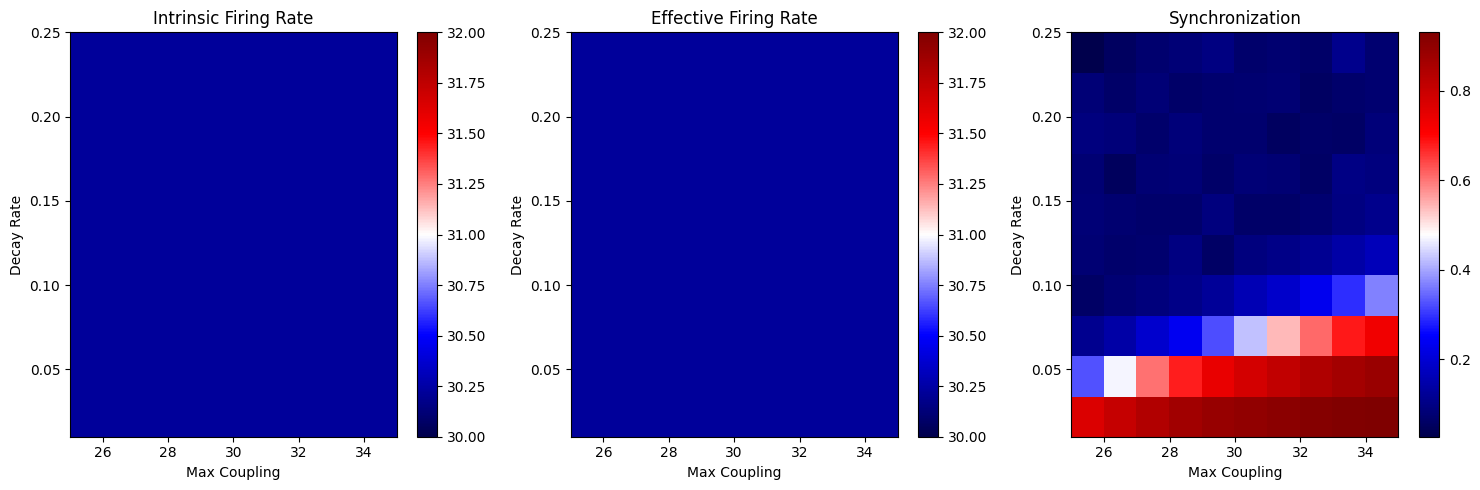

In [70]:
vmin = 30
vmax = 32

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im1 = axs[0].imshow(np.round(intrinsic_firing, 2), extent=(25, 35, 0.01, 0.25), cmap='seismic', origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
axs[0].set_title('Intrinsic Firing Rate')
axs[0].set_xlabel('Max Coupling')
axs[0].set_ylabel('Decay Rate')
cbar1 = fig.colorbar(im1, ax=axs[0])
cbar1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

im2 = axs[1].imshow(np.round(effective_firing, 2), extent=(25, 35, 0.01, 0.25), cmap='seismic',origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
axs[1].set_title('Effective Firing Rate')
axs[1].set_xlabel('Max Coupling')
axs[1].set_ylabel('Decay Rate')
cbar2 = fig.colorbar(im2, ax=axs[1])
cbar2.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

im3 = axs[2].imshow(synchronization, extent=(25, 35, 0.01, 0.25),cmap='seismic', origin='lower', aspect='auto')
axs[2].set_title('Synchronization')
axs[2].set_xlabel('Max Coupling')
axs[2].set_ylabel('Decay Rate')
fig.colorbar(im3, ax=axs[2])
plt.tight_layout()
plt.show()

In [71]:
print(f'Are intrinsic and effective firing rates practically equal? {np.allclose(intrinsic_firing.flatten(), effective_firing.flatten())}')
print(f'Total difference: {np.sum(np.abs(intrinsic_firing.flatten() - effective_firing.flatten()))}')

Are intrinsic and effective firing rates practically equal? True
Total difference: 6.0538241086760536e-12
